In [ ]:
## Bloco de codigo para instalar versao especifica dos pacotes
##pip install pandas==1.5.3
##pip install numpy==1.24.3

# Carregando pacotes

In [20]:
# Pacotes de manipulacao

import pandas as pd
import numpy as np
import os

# Pacotes de visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 1.5.3
numpy: 1.24.3


## Carregando databases

#### Base Dados Cadastrais

In [3]:
## Carregando todos arquivos em parquet de uma pasta

path = 'database/raw/base_dados_cadastrais'

all_files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.parquet')]
df_list = [pd.read_parquet(f, engine='pyarrow') for f in all_files]

df_base_dados_cadastrais = pd.concat(df_list, ignore_index=True)

In [4]:
df_base_dados_cadastrais.head()

,NUM_CPF,SAFRA,FLAG_INSTALACAO,FPD,PROD,flag_mig2,STATUSRF,DATADENASCIMENTO,var_03,var_02,...,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,CEP_3_digitos
0,77789989YZZ,202503,1,0,CMV,PRE,REGULAR,09/09/1984,33,None,...,None,None,AUX_EMRG,None,FUNC_PRIVADO,None,None,ADMITIDO,AUX_EMRG FUNC_PRIVADO,768
1,7778TYWXT9X,202412,1,0,CMV,Aquisição,REGULAR,16/08/1979,None,None,...,None,None,None,None,FUNC_PRIVADO,EMPR/DIRETOR,None,ADMITIDO,FUNC_PRIVADO EMPR/DIRETOR,490
2,7778XUZNYU9,202410,1,0,CMV,PRE,REGULAR,23/07/1981,4,None,...,None,None,None,None,FUNC_PRIVADO,None,None,DISPENSADO,FUNC_PRIVADO,689
3,7778YY8WZZZ,202411,0,None,CMV,None,REGULAR,10/01/1976,48,None,...,None,None,AUX_EMRG,None,FUNC_PRIVADO,None,None,ADMITIDO,AUX_EMRG FUNC_PRIVADO,934
4,7779TX8ZTXT,202410,1,1,CMV,Aquisição,REGULAR,24/02/1982,4,None,...,None,None,None,None,FUNC_PRIVADO,EMPR/DIRETOR,None,DISPENSADO,FUNC_PRIVADO EMPR/DIRETOR,455


### Funções

Bloco destinado a criação das funcoes que serao utilizados ao longo deste notebook

In [7]:
# Metadados referente ao conjunto de dados
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata=metadata.sort_values(by='percent_nulos',ascending=True)
    metadata = metadata.reset_index(drop=True)

    return metadata

### Analise dos dados

In [8]:
generate_metadata(df_base_dados_cadastrais)

,nome_variavel,tipo,qt_nulos,percent_nulos,cardinalidade
0,NUM_CPF,object,0,0.00,3590459
1,SAFRA,object,0,0.00,6
2,FLAG_INSTALACAO,object,0,0.00,2
3,PROD,object,0,0.00,3
4,var_04,object,15154,0.39,6
5,STATUSRF,object,15154,0.39,6
6,DATADENASCIMENTO,object,16831,0.43,30046
7,var_05,object,196424,5.04,10
8,var_03,object,269970,6.92,100
9,CEP_3_digitos,object,292051,7.49,922


Olhando os metadados de cada coluna, ja podemos observar que:
- Metade das colunas possuem um percentual de nulos superior a 50%
- 25 colunas com o nome apenas como VAR_n
- Todas as colunas estao com o data type object

### Analise univariada

Antes de seguirmos com a estruturação da tabela iremos analisar como os dados estão distribuidos.
Seguiremos com a ordem das colunas com o menor para o maior percentual de nulos.

#### 01 - Safra

In [17]:
df_base_dados_cadastrais['SAFRA'].value_counts().sort_index()

202410    653586
202411    665737
202412    646037
202501    667227
202502    619961
202503    647830
Name: SAFRA, dtype: int64

In [18]:
print('Inicio da safra: ', df_base_dados_cadastrais['SAFRA'].min())
print('Fim da safra: ', df_base_dados_cadastrais['SAFRA'].max())

Inicio da safra:  202410
Fim da safra:  202503


Para o processo de ETL:
- Nome: Safra
- Transformar coluna em INT
- Criar duas novas colunas: Ano e Mes

#### 02 - FLAG_INSTALACAO

In [27]:
df_base_dados_cadastrais['FLAG_INSTALACAO'].value_counts()

1    2696621
0    1203757
Name: FLAG_INSTALACAO, dtype: int64

In [29]:
# Iremos transformar essa coluna em tipo numerico
df_base_dados_cadastrais['FLAG_INSTALACAO'] = df_base_dados_cadastrais['FLAG_INSTALACAO'].astype('boolean')

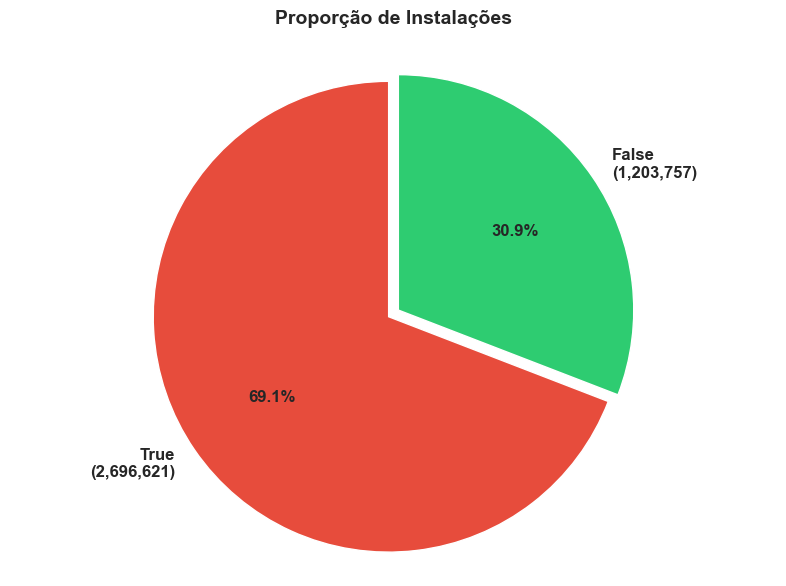

In [32]:
dados = df_base_dados_cadastrais['FLAG_INSTALACAO'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71']  # vermelho e verde
explode = (0.05, 0)  # destaca a primeira fatia

plt.pie(
    dados.values,
    labels=[f'{label}\n({value:,})' for label, value in zip(dados.index, dados.values)],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Proporção de Instalações', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

Para o processo de ETL:
- Nome: IsSetup ou IsInstallation
- Tipo de dado: boolean

#### 03 - PROD

In [41]:
df_base_dados_cadastrais['PROD'].value_counts()

CMV    3795310
NET      89968
DTH      15100
Name: PROD, dtype: int64

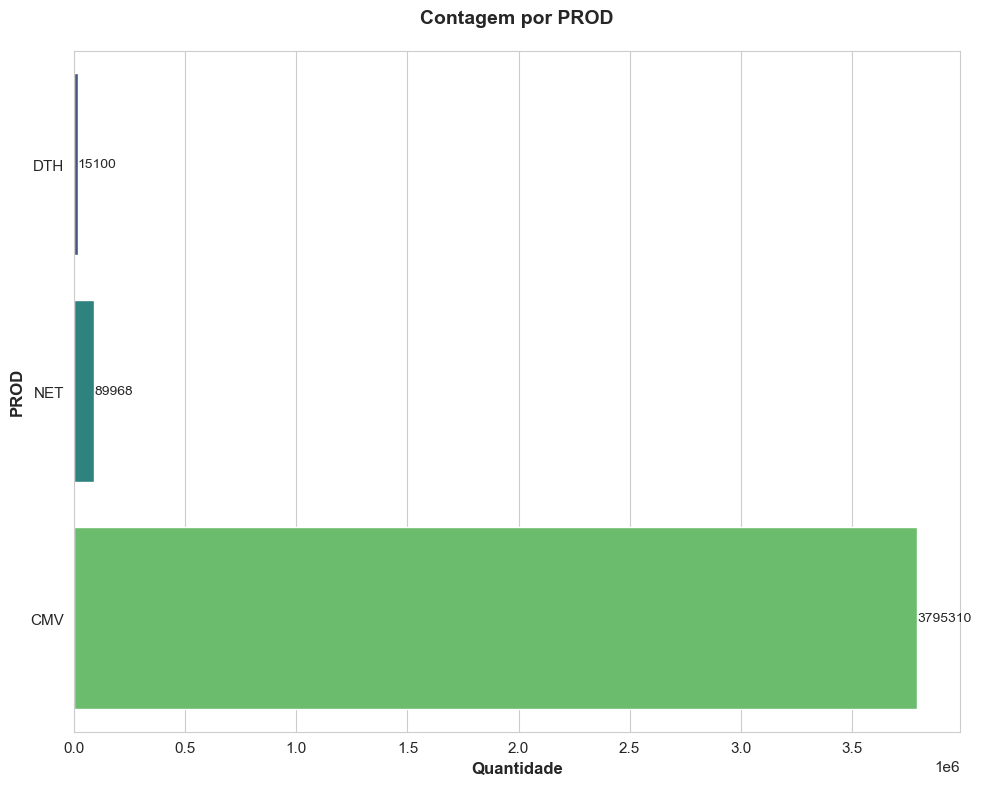

In [42]:
# Preparar dados agregados
dados_agregados = df_base_dados_cadastrais.groupby('PROD').size().reset_index(name='count')
dados_agregados = dados_agregados.sort_values('count', ascending=True)  # ordena para melhor visualização

plt.figure(figsize=(10, 8))
sns.barplot(
    data=dados_agregados,
    y='PROD',
    x='count',
    palette='viridis',
    orient='h'
)

plt.title('Contagem por PROD', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Quantidade', fontsize=12, fontweight='bold')
plt.ylabel('PROD', fontsize=12, fontweight='bold')

# Adicionar valores nas barras
for i, v in enumerate(dados_agregados['count']):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

Para o processo de ETL:
- Nome: ProductDescription
- Tipo de dado: Varchar

#### 04 - var_04

In [39]:
df_base_dados_cadastrais['var_04'].value_counts()

0    3468813
1     247171
2      99910
3      39738
4      16063
5      13529
Name: var_04, dtype: int64

#### 05 - STATUSRF

In [40]:
df_base_dados_cadastrais['STATUSRF'].value_counts()

REGULAR                      3848697
PENDENTE DE REGULARIZACAO      31217
SUSPENSA                        2689
TITULAR FALECIDO                2398
CANCELADA                        222
NULA                               1
Name: STATUSRF, dtype: int64

Para o processo de ETL:
- Nome: StatusReceitaFederal
- Tipo de dado: Varchar

#### 05 - DATADENASCIMENTO

In [45]:
# Primeiro iremos transformar a coluna DATADENASCIMENTO para o tipo datetime
df_base_dados_cadastrais['DATADENASCIMENTO'] = pd.to_datetime(df_base_dados_cadastrais['DATADENASCIMENTO'], errors='coerce')

C:\Users\alexandre.junior\AppData\Local\Temp\ipykernel_7484\2150148096.py:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df_base_dados_cadastrais['DATADENASCIMENTO'] = pd.to_datetime(df_base_dados_cadastrais['DATADENASCIMENTO'], errors='coerce')


In [46]:
print('Data minima:', df_base_dados_cadastrais['DATADENASCIMENTO'].min())
print('Data maxima:', df_base_dados_cadastrais['DATADENASCIMENTO'].max())

Data minima: 1893-06-06 00:00:00
Data maxima: 2020-06-24 00:00:00


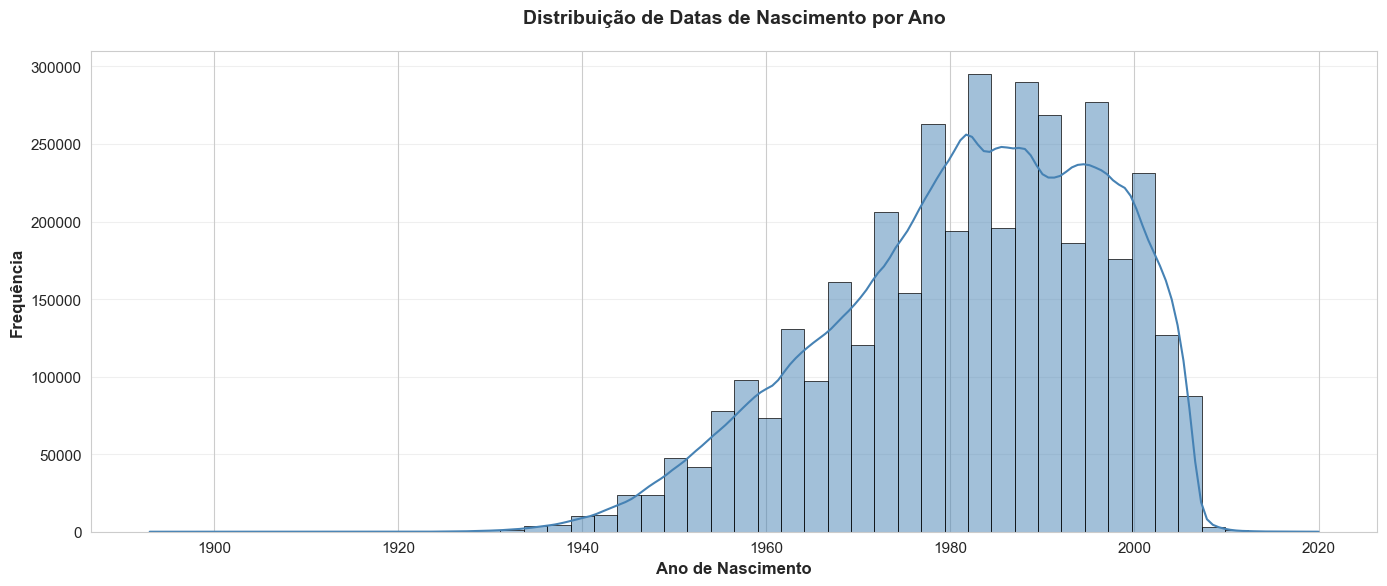

In [48]:
# Vamos analisar como esta distribuida a data de nascimento dos registros

plt.figure(figsize=(14, 6))
sns.histplot(
    data=df_base_dados_cadastrais,
    x= df_base_dados_cadastrais['DATADENASCIMENTO'].dt.year,
    bins=50,  # ajuste conforme necessário
    kde=True,  # linha de densidade
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)

plt.title('Distribuição de Datas de Nascimento por Ano', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Ano de Nascimento', fontsize=12, fontweight='bold')
plt.ylabel('Frequência', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Para o processo de analise:
- Entender como se comportam os clientes que possuem uma data de nascimento anterior a 1960 e superior a 2017 (menor de 18 anos).
- Analise multivariada com a informação do Status da Receita Federal

Para o processo de ETL:
- Nome: BirthdayDate
- Tipo de dados: Datetime